| Method                | How It Works                                                                 | Strengths                                      | Weaknesses                                   | When to Use                                |
|------------------------|-------------------------------------------------------------------------------|------------------------------------------------|----------------------------------------------|---------------------------------------------|
| **GridSearchCV**       | Exhaustively tries all combinations of specified hyperparameters.             | - Guarantees finding best combination in search space<br>- Deterministic results | - Computationally expensive<br>- Slow for large parameter grids | Small parameter spaces, when exact best parameters are needed |
| **RandomizedSearchCV** | Samples a fixed number of parameter settings from specified distributions.    | - Much faster for large search spaces<br>- Can explore wide ranges<br>- Flexible distributions | - May miss optimal parameters<br>- Results vary between runs | Large parameter spaces, limited compute time, exploratory tuning |


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
X, y = load_iris(return_X_y=True)

# Base model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None] + list(np.arange(3, 15)),
    'max_features': ['sqrt', 'log2', None]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X, y)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,  # number of random samples
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)

# Results
print("GridSearchCV Best Params:", grid_search.best_params_)
print("GridSearchCV Best Score:", grid_search.best_score_)

print("RandomizedSearchCV Best Params:", random_search.best_params_)
print("RandomizedSearchCV Best Score:", random_search.best_score_)


You usually use CV to avoid allocating a validation set for the data you're testing

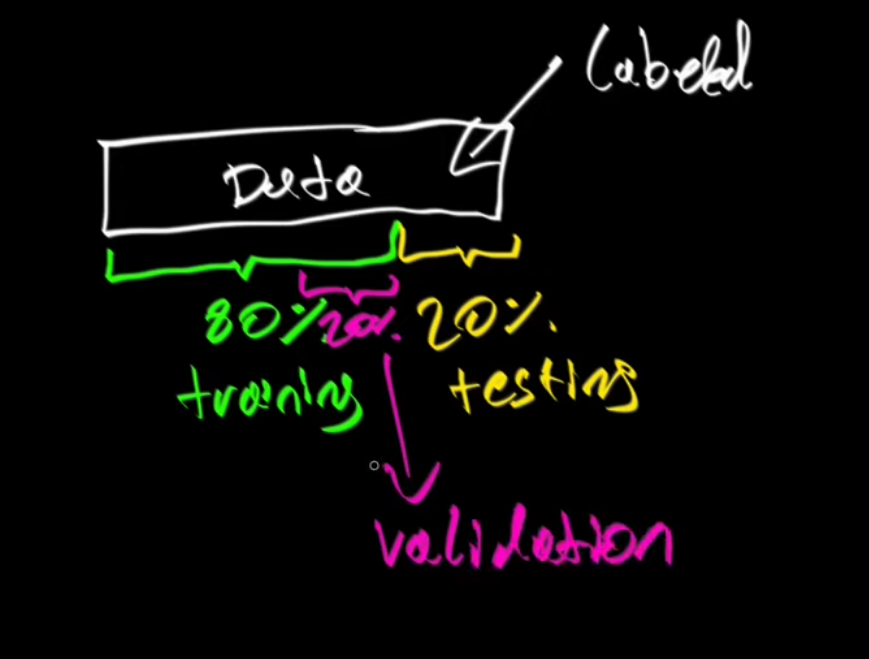

Do this by separating into folds where one fold can be the evaluated

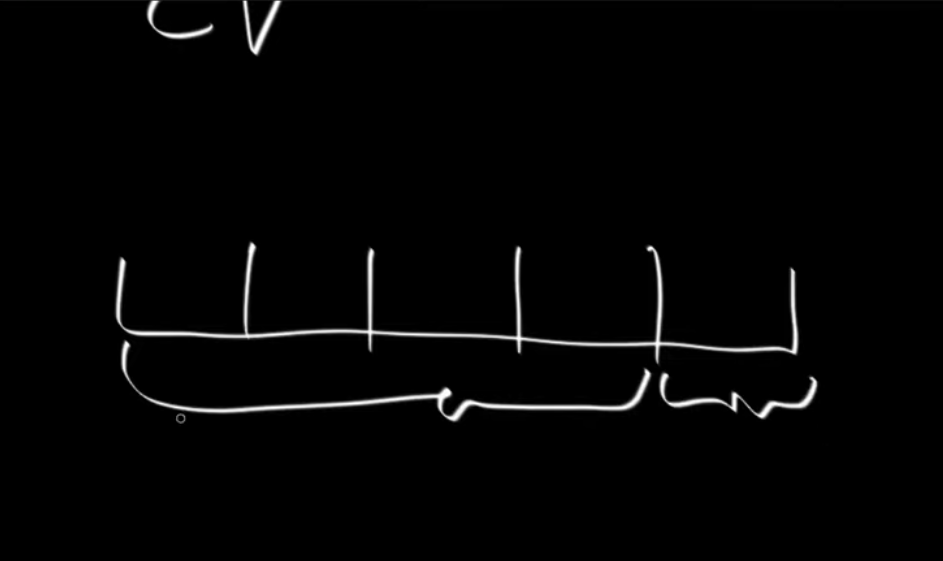

Normal setup

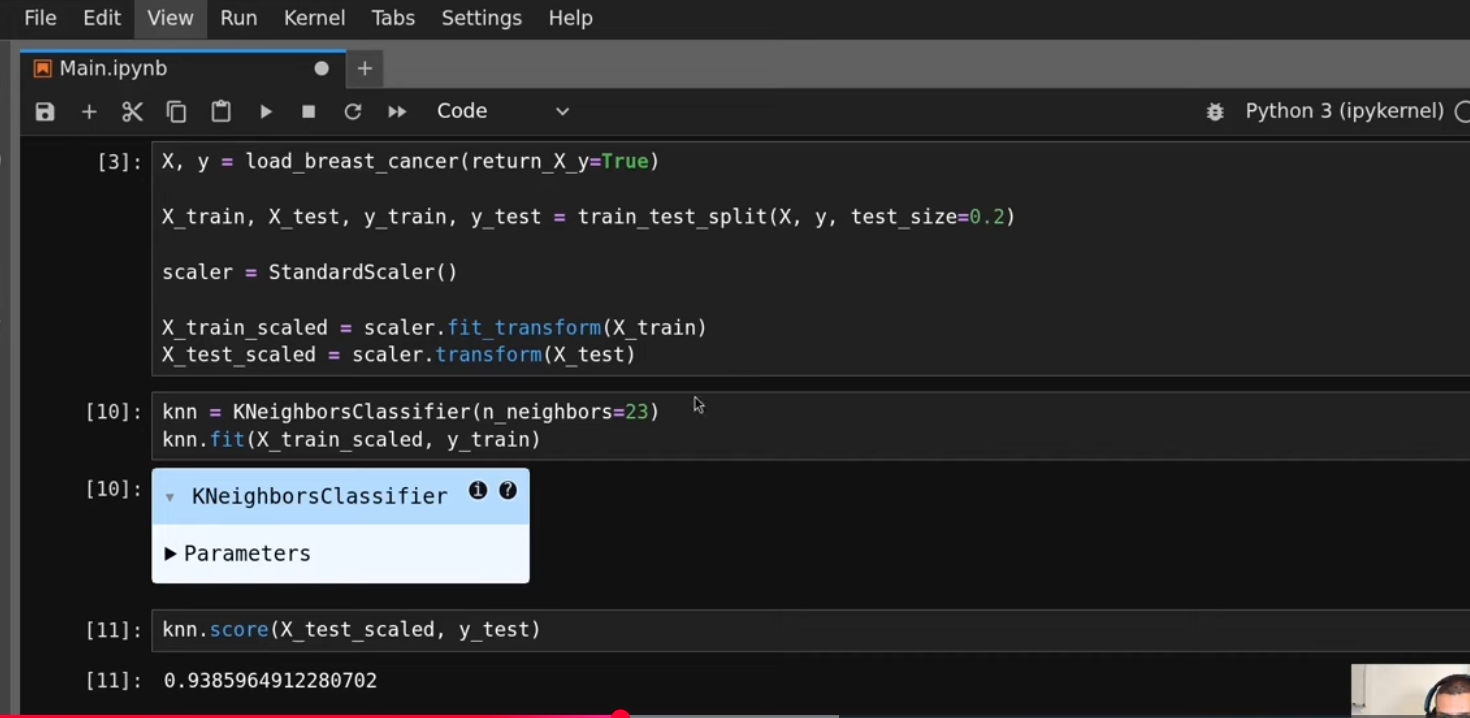

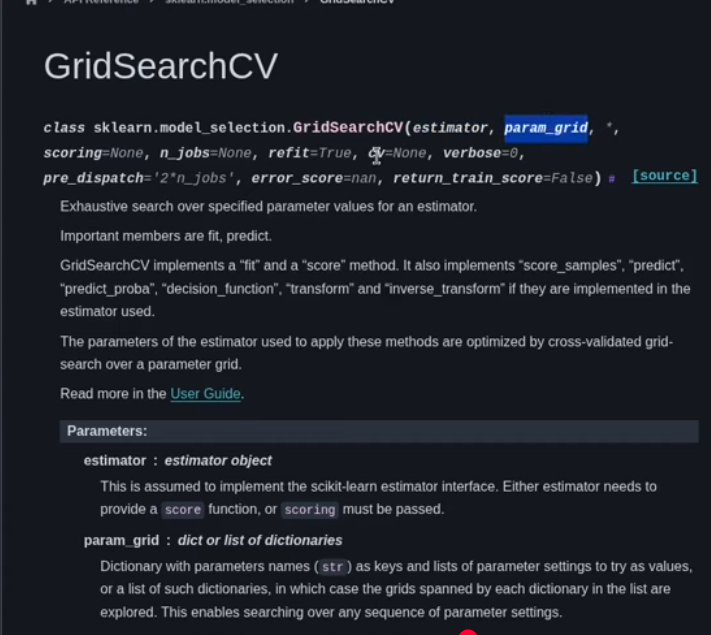

You basically have to provide a paramater grid that the name of hyperparams and then the respective values that you want to try with that model. After you can ask for the settings with the best estimator

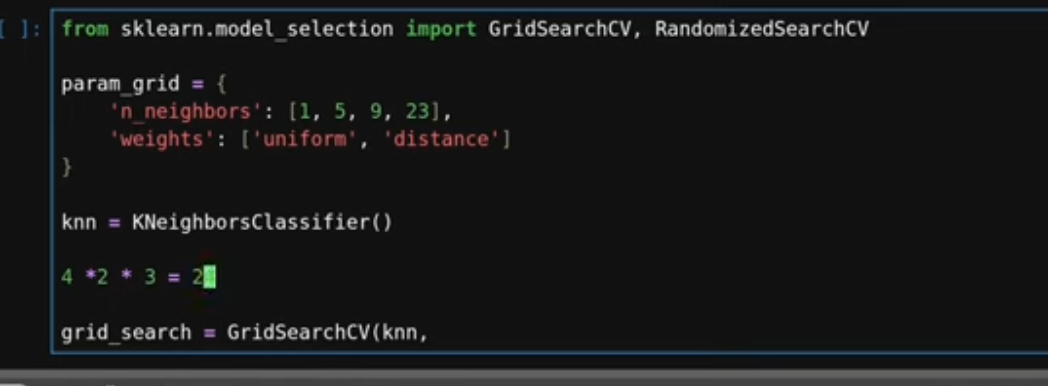

noe about cv and how it adds to the complexity

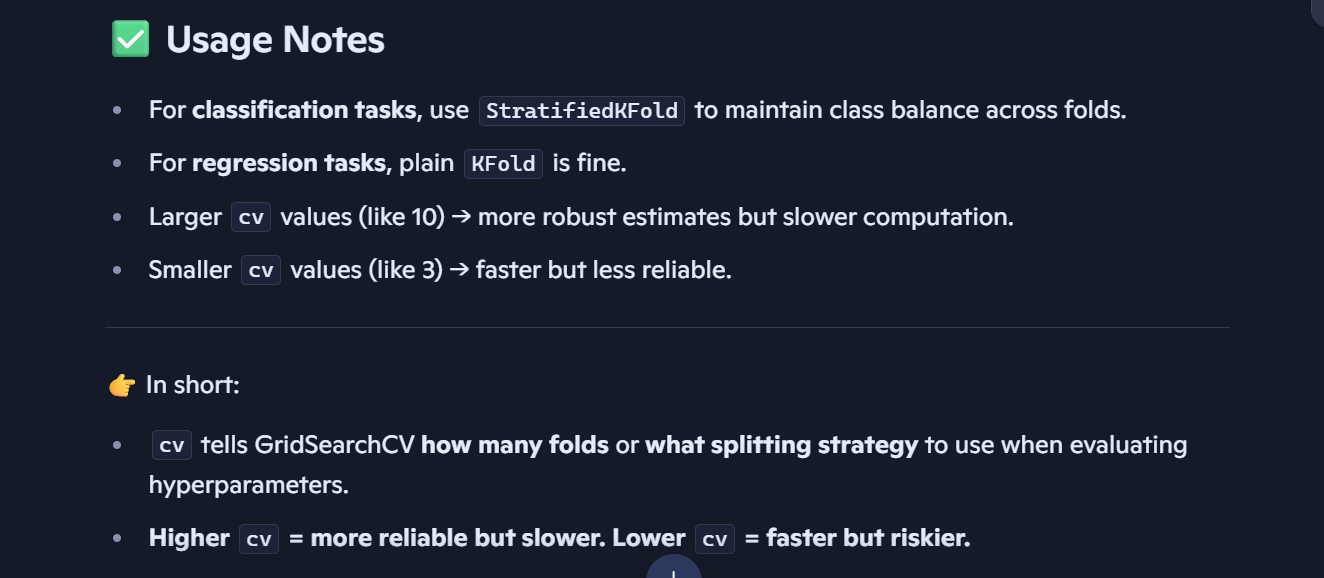

### GridSearch

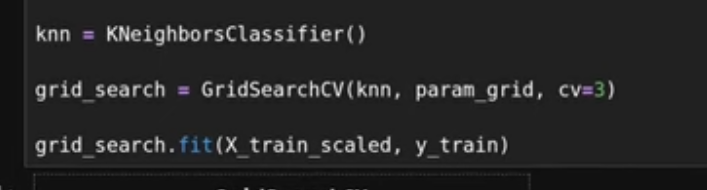

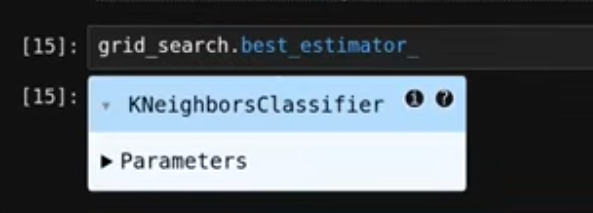

if you want to directly feed the best params, it might be best to make a variable and then set that variable to the typeofserach.best_params

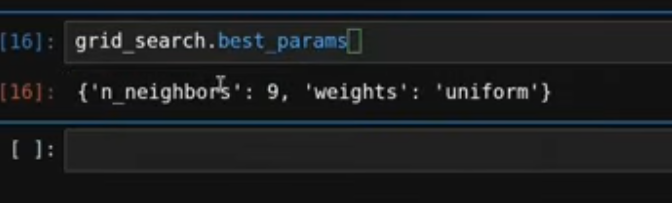

### RandomizedSearch

best for large datasets or  hyperparams with continuos data

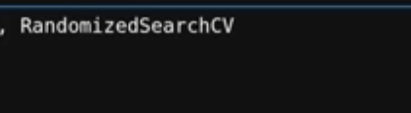

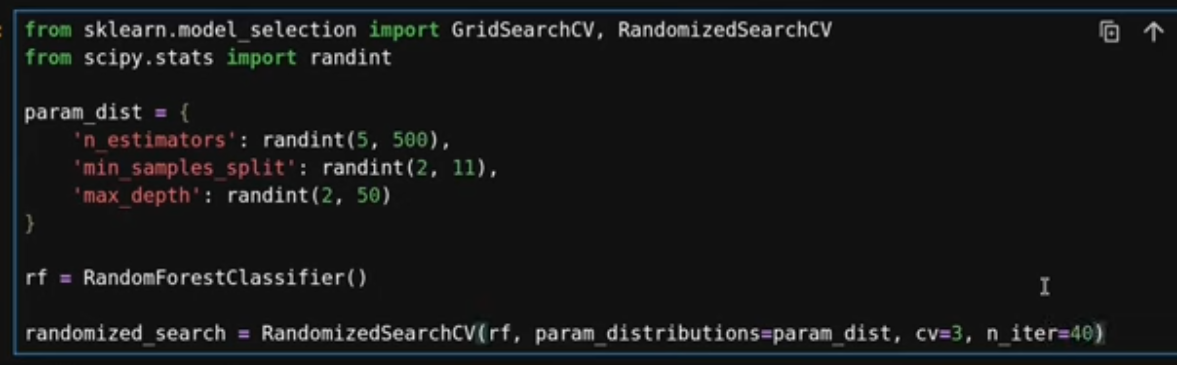

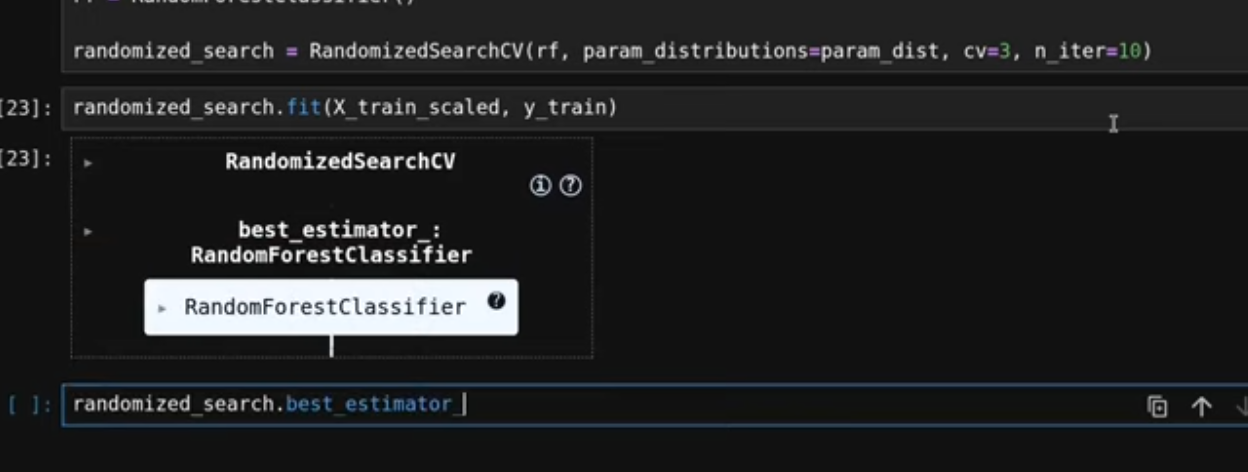

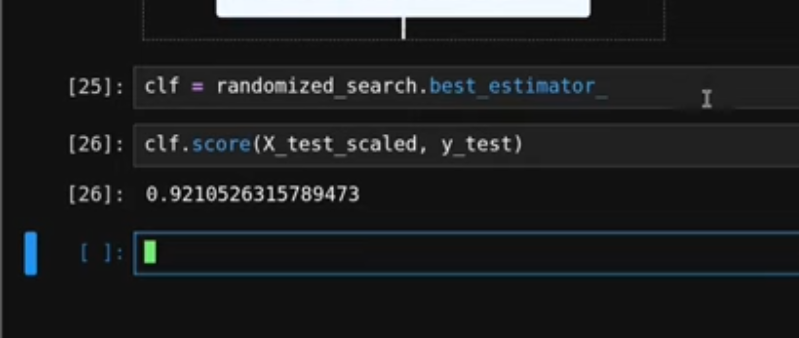

GridSearchCV exhaustively checks all combinations in param_grid.

RandomizedSearchCV samples a fixed number (n_iter) of combinations from param_distributions.

You’ll see different best parameters and scores depending on the search strategy.